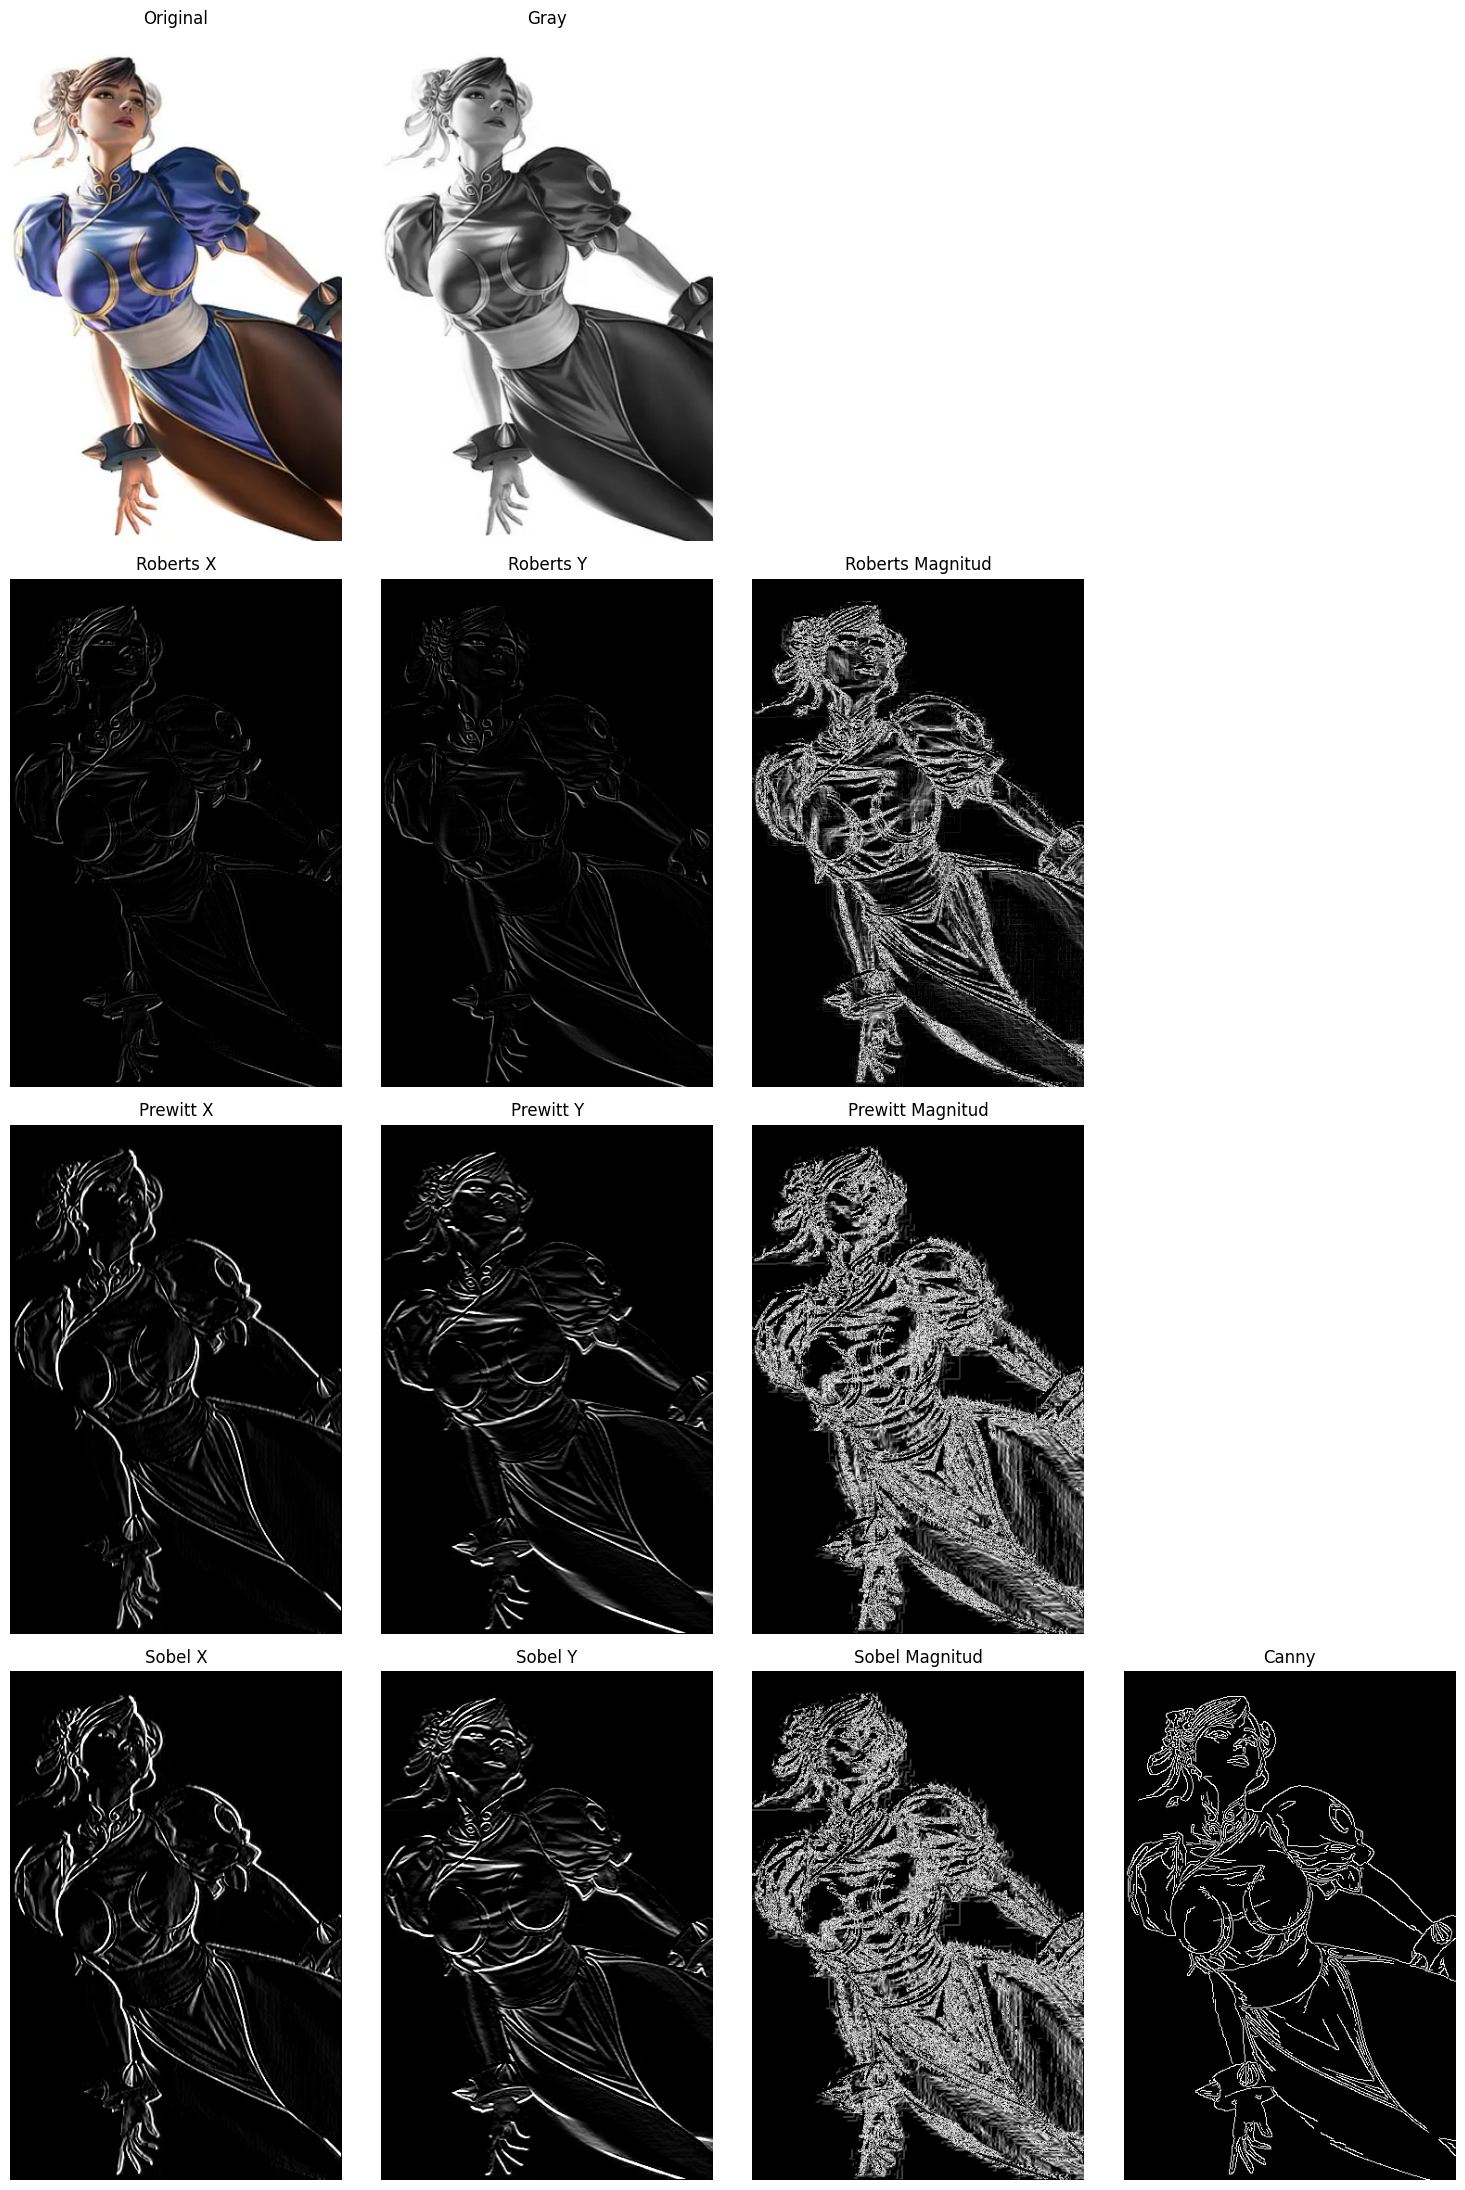

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('chi.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#ROBERTS
robertx = np.array([[-1, 0], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])

robx_img = cv2.filter2D(gray, -1, robertx)
roby_img = cv2.filter2D(gray, -1, roberty)
rob_mag = np.sqrt(robx_img**2 + roby_img**2)

#PREWIT
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

prex_img = cv2.filter2D(gray, -1, prewitt_x)
prey_img = cv2.filter2D(gray, -1, prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)

#SOBEL
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)

#CANNY 
canny_img = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(15,22))

# FILA 1
plt.subplot(4,4,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(4,4,2); plt.title("Gray"); plt.imshow(gray, cmap='gray'); plt.axis('off')

# ROBERTS
plt.subplot(4,4,5); plt.title("Roberts X"); plt.imshow(robx_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,6); plt.title("Roberts Y"); plt.imshow(roby_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,7); plt.title("Roberts Magnitud"); plt.imshow(rob_mag, cmap='gray'); plt.axis('off')

# PREWITT
plt.subplot(4,4,9); plt.title("Prewitt X"); plt.imshow(prex_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,10); plt.title("Prewitt Y"); plt.imshow(prey_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,11); plt.title("Prewitt Magnitud"); plt.imshow(prewitt_mag, cmap='gray'); plt.axis('off')

# SOBEL
plt.subplot(4,4,13); plt.title("Sobel X"); plt.imshow(sobelx_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,14); plt.title("Sobel Y"); plt.imshow(sobely_img, cmap='gray'); plt.axis('off')
plt.subplot(4,4,15); plt.title("Sobel Magnitud"); plt.imshow(sobel_mag, cmap='gray'); plt.axis('off')

# CANNY
plt.subplot(4,4,16); plt.title("Canny"); plt.imshow(canny_img, cmap='gray'); plt.axis('off')

plt.tight_layout()
plt.show()

SOBEL

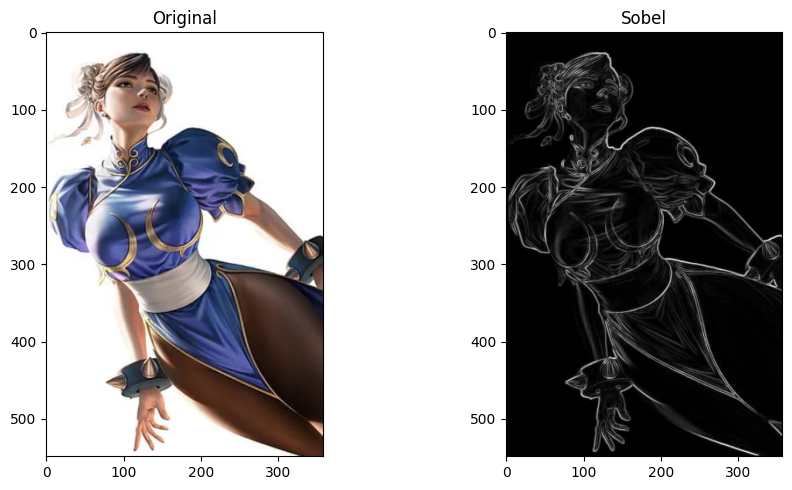

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img = cv2.imread('chi.png')


resultado = filtro_sobel(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Sobel")
plt.imshow(resultado, cmap='gray')

plt.tight_layout()
plt.show()

Sobel mejorado

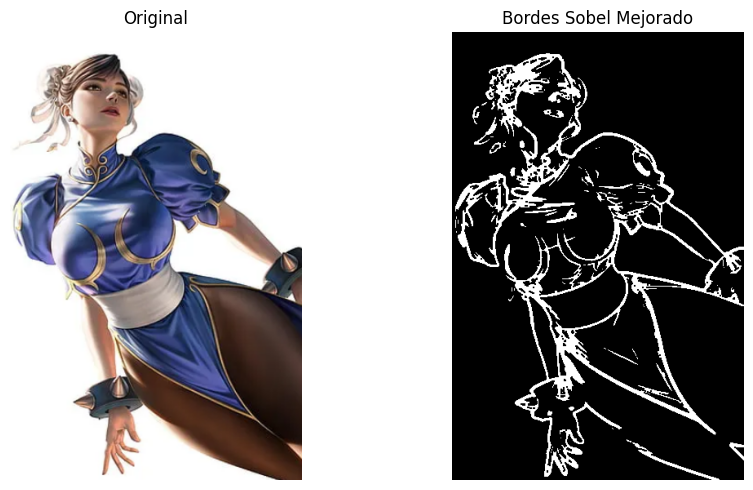

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # filtro gaussiano para mejorar detección
    img_gris = cv2.GaussianBlur(img_gris, (3,3), 0)

    # gradientes
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    # magnitud
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # umbralización + Otsu
    _, bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # cierre morfológico
    kernel_m = np.ones((2,2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)

    return bordes


img = cv2.imread('chi.png')

resultado = filtro_sobel(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Bordes Sobel Mejorado")
plt.imshow(resultado, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Robert

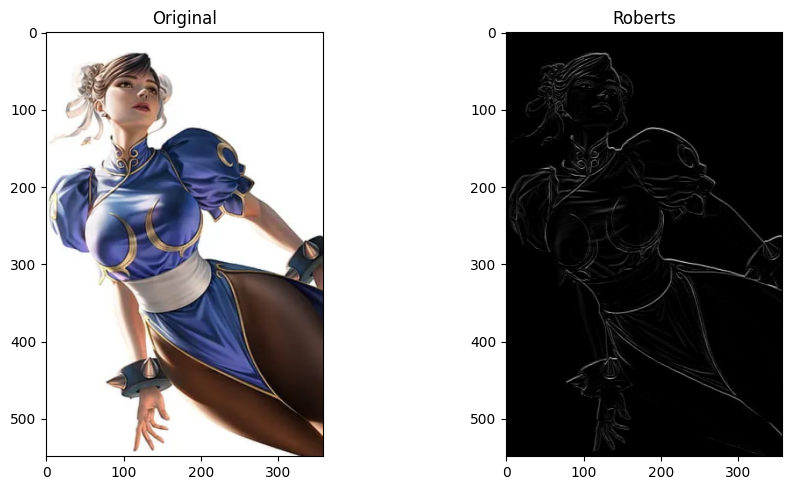

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertx = np.array([[1, 0], [0, -1]], dtype=np.float32)
    roberty = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)

    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('chi.png')

resultado = filtro_roberts(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Roberts")
plt.imshow(resultado, cmap='gray')

plt.tight_layout()
plt.show()